In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
import time
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [3]:
from deepface import DeepFace
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import confusion_matrix, classification_report
from numpy.linalg import norm

DB_DIR = Path("./faces")
MODEL_NAME = "Facenet512"
DETECTOR   = "mtcnn"
THRESHOLD  = 0.30

N_KNOWN_PEOPLE   = 25
N_ENROLL         = 4
N_TEST_KNOWN     = 5
N_UNKNOWN_PEOPLE = 25
N_TEST_UNKNOWN   = 1

26-09-21 16:00:45 - ⚠️ 
 ⚠️ DEPRECATION WARNING:
 Running 'pip install deepface' alone will no longer be sufficient and will
 NOT install a default backend in an upcoming major release.

 Currently, TensorFlow is included by default, but this behavior will be deprecated.
 Please explicitly specify your preferred backend engine when installing:

   -> pip install deepface[tensorflow]
   -> pip install deepface[pytorch]

 Otherwise, you will encounter 'module not found' errors.




In [4]:
lfw = fetch_lfw_people(min_faces_per_person=10, color=True, resize=1.0, funneled=True)
images = (lfw.images * 255).astype(np.uint8)
labels = lfw.target
names  = lfw.target_names
print(f"Всего: {len(images)} фото, {len(names)} человек")

Всего: 4324 фото, 158 человек


In [5]:
counts = np.bincount(labels)
order  = np.argsort(-counts)
known_ids   = order[:N_KNOWN_PEOPLE]
unknown_ids = order[N_KNOWN_PEOPLE:N_KNOWN_PEOPLE + N_UNKNOWN_PEOPLE]

lfw_known   = {names[p].replace(" ", "_") for p in known_ids}
lfw_unknown = {names[p].replace(" ", "_") for p in unknown_ids}

In [6]:
def save(arr, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(arr).save(path, quality=95)

for sub in ("known", "test/known", "test/unknown"):
    (DB_DIR / sub).mkdir(parents=True, exist_ok=True)

for d in (DB_DIR / "known").iterdir():
    if d.is_dir() and not d.name.startswith(".") and d.name in lfw_known:
        shutil.rmtree(d)
for f in (DB_DIR / "test" / "known").glob("*.jpg"):
    if f.stem.split("__")[0] in lfw_known:
        f.unlink()
for f in (DB_DIR / "test" / "unknown").glob("*.jpg"):
    if f.stem.split("__")[0] in lfw_unknown:
        f.unlink()

In [7]:
n_enrolled = n_test_known = n_test_unknown = 0
for pid in known_ids:
    person = names[pid].replace(" ", "_")
    idx = np.where(labels == pid)[0]
    for i, j in enumerate(idx[:N_ENROLL]):
        save(images[j], DB_DIR / "known" / person / f"{i + 1}.jpg")
        n_enrolled += 1
    for i, j in enumerate(idx[N_ENROLL:N_ENROLL + N_TEST_KNOWN]):
        save(images[j], DB_DIR / "test" / "known" / f"{person}__{i + 1}.jpg")
        n_test_known += 1
for pid in unknown_ids:
    person = names[pid].replace(" ", "_")
    for i, j in enumerate(np.where(labels == pid)[0][:N_TEST_UNKNOWN]):
        save(images[j], DB_DIR / "test" / "unknown" / f"{person}__{i + 1}.jpg")
        n_test_unknown += 1

print(f"Из LFW: {len(known_ids)} человек, {n_enrolled} эталонов")
print(f"Тест:   {n_test_known} своих + {n_test_unknown} чужих")

Из LFW: 25 человек, 100 эталонов
Тест:   125 своих + 25 чужих


In [8]:
def get_embedding_with_flag(img_path):
    try:
        reps = DeepFace.represent(
            img_path=str(img_path),
            model_name=MODEL_NAME,
            detector_backend=DETECTOR,
            enforce_detection=True,
            align=False,
            normalization="base",
        )
        emb = np.array(reps[0]["embedding"], dtype=np.float32)
        return emb, True
    except ValueError as e:
        return None, False
    except Exception as e:
        print(f"Ошибка при обработке {img_path}: {e}")
        return None, False

In [9]:
def get_embedding(img_path):
    emb, _ = get_embedding_with_flag(img_path)
    return emb

In [10]:
db_embeddings, db_paths = {}, {}
skipped_db = []
non_faces = []

for person_dir in sorted((DB_DIR / "known").iterdir()):
    if not person_dir.is_dir() or person_dir.name.startswith("."):
        continue
    person = person_dir.name
    embs, paths = [], []
    for img_path in sorted(person_dir.glob("*.jpg")):
        emb, face_found = get_embedding_with_flag(img_path)
        if not face_found or emb is None:
            skipped_db.append((person, img_path.name))
            non_faces.append(img_path)
            continue
        embs.append(emb)
        paths.append(img_path)
    if embs:
        db_embeddings[person] = embs
        db_paths[person]      = paths
        print(f"{person}: {len(embs)} эмбеддингов")
    else:
        print(f"{person}: эмбеддинг не получен")

if non_faces:
    print(f"\nНе лица (лицо не найдено): {len(non_faces)}")
    for p in non_faces[:10]:
        print(f"  {p}")

Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\myfam\anaconda3\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\myfam\anaconda3\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\myfam\anaconda3\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


Alejandro_Toledo: 4 эмбеддингов
Alien: 1 эмбеддингов
Alvaro_Uribe: 4 эмбеддингов
Andre_Agassi: 4 эмбеддингов
Ariel_Sharon: 4 эмбеддингов
Arnold_Schwarzenegger: 4 эмбеддингов
Colin_Powell: 4 эмбеддингов
Donald_Rumsfeld: 4 эмбеддингов
George_W_Bush: 4 эмбеддингов
Gerhard_Schroeder: 4 эмбеддингов
Gloria_Macapagal_Arroyo: 4 эмбеддингов
Hans_Blix: 4 эмбеддингов
Hugo_Chavez: 4 эмбеддингов
Jacques_Chirac: 4 эмбеддингов
Jean_Chretien: 4 эмбеддингов
Jennifer_Capriati: 4 эмбеддингов
John_Ashcroft: 4 эмбеддингов
Junichiro_Koizumi: 4 эмбеддингов
Laura_Bush: 4 эмбеддингов
Lleyton_Hewitt: 4 эмбеддингов
Luiz_Inacio_Lula_da_Silva: 4 эмбеддингов
Nestor_Kirchner: 4 эмбеддингов
Not_Face: эмбеддинг не получен
Serena_Williams: 3 эмбеддингов
Silvio_Berlusconi: 4 эмбеддингов
Tony_Blair: 4 эмбеддингов
Vladimir_Putin: 4 эмбеддингов

Не лица (лицо не найдено): 3
  faces\known\Alien\1.jpg
  faces\known\Not_Face\1.jpg
  faces\known\Serena_Williams\1.jpg


In [11]:
def cosine_distance(a, b):
    a = a / (norm(a) + 1e-10)
    b = b / (norm(b) + 1e-10)
    return 1.0 - float(np.dot(a, b))

def recognize(img_path, threshold=THRESHOLD):
    emb = get_embedding(img_path)
    if emb is None:
        return "Unknown", None, None
    best_person, best_dist = "Unknown", float("inf")
    for person, embs in db_embeddings.items():
        for db_emb in embs:
            d = cosine_distance(emb, db_emb)
            if d < best_dist:
                best_dist, best_person = d, person
    if best_dist > threshold:
        return "Unknown", best_person, best_dist
    return best_person, best_person, best_dist

In [12]:
results = []
for kind in ("known", "unknown"):
    for img_path in sorted((DB_DIR / "test" / kind).glob("*.jpg")):
        true_name = img_path.stem.split("__")[0]
        emb, face_found = get_embedding_with_flag(img_path)

        if not face_found:
            results.append({
                "file": img_path.name, "true": true_name,
                "pred": "NoFace", "best": None, "dist": None,
                "type": kind, "face_found": False,
            })
            continue

        pred, best, dist = recognize(img_path)
        results.append({
            "file": img_path.name, "true": true_name,
            "pred": pred, "best": best, "dist": dist,
            "type": kind, "face_found": True,
        })

df = pd.DataFrame(results)

no_face_df = df[~df["face_found"]]
print(f"\nКартинок без лица: {len(no_face_df)} из {len(df)}")
if len(no_face_df):
    display(no_face_df[["file", "true", "type"]])


Картинок без лица: 4 из 157


,file,true,type
103,Nestor_Kirchner__3.jpg,Nestor_Kirchner,known
106,Not_Face.jpg,Not_Face,known
108,Serena_Williams__2.jpg,Serena_Williams,known
110,Serena_Williams__4.jpg,Serena_Williams,known


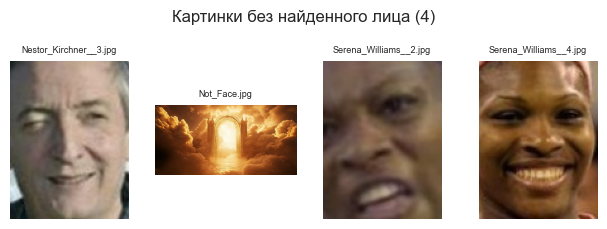

In [13]:
if len(no_face_df) > 0:
    n = len(no_face_df)
    ncol = min(10, n)
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(1.6 * ncol, 2.2 * nrow))
    axes = np.array(axes).reshape(-1)
    for ax, (_, row) in zip(axes, no_face_df.iterrows()):
        p = DB_DIR / "test" / row["type"] / row["file"]
        ax.imshow(Image.open(p))
        ax.set_title(row["file"], fontsize=6.5)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"Картинки без найденного лица ({n})", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Все картинки содержат лицо")

In [14]:
known_df   = df[df["type"] == "known"]
unknown_df = df[df["type"] == "unknown"]
acc_known   = (known_df["true"]   == known_df["pred"]).mean()
acc_unknown = (unknown_df["pred"] == "Unknown").mean()
acc_all = df.apply(
    lambda r: r["pred"] == r["true"] if r["type"] == "known" else r["pred"] == "Unknown",
    axis=1
).mean()

print(f"\nAccuracy на своих:          {acc_known:.3f}  ({int(acc_known*len(known_df))}/{len(known_df)})")
print(f"Accuracy на чужих (Unknown): {acc_unknown:.3f}  ({int(acc_unknown*len(unknown_df))}/{len(unknown_df)})")
print(f"Общая accuracy:              {acc_all:.3f}")


Accuracy на своих:          0.850  (108/127)
Accuracy на чужих (Unknown): 0.767  (23/30)
Общая accuracy:              0.834


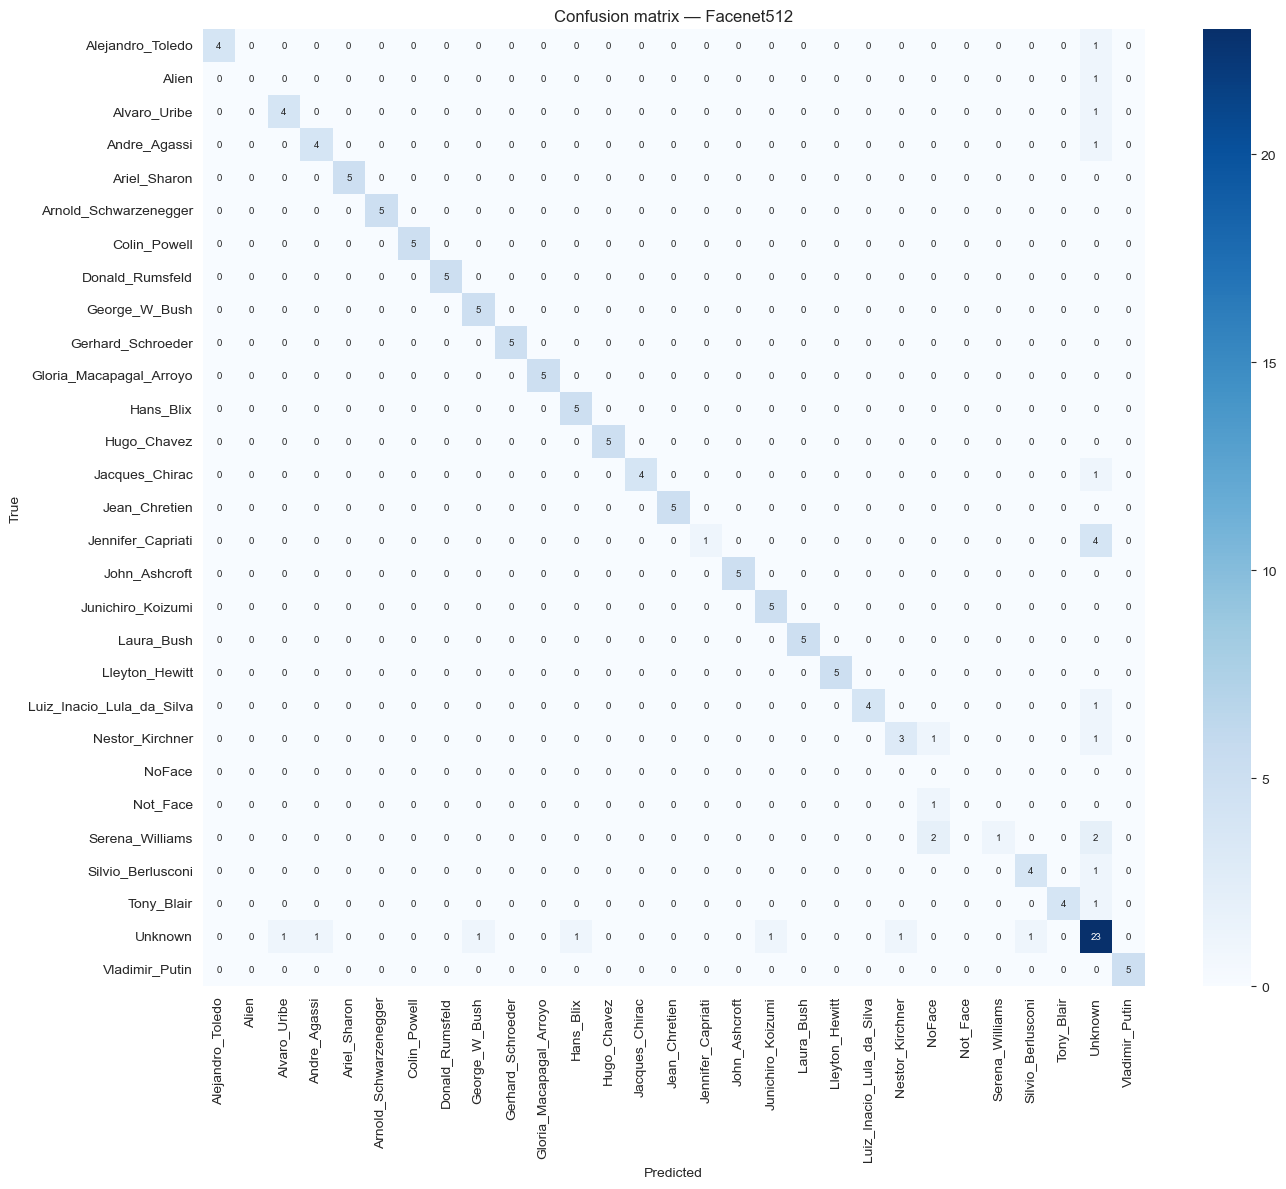

                           precision    recall  f1-score   support

         Alejandro_Toledo       1.00      0.80      0.89         5
                    Alien       0.00      0.00      0.00         1
             Alvaro_Uribe       0.80      0.80      0.80         5
             Andre_Agassi       0.80      0.80      0.80         5
             Ariel_Sharon       1.00      1.00      1.00         5
    Arnold_Schwarzenegger       1.00      1.00      1.00         5
             Colin_Powell       1.00      1.00      1.00         5
          Donald_Rumsfeld       1.00      1.00      1.00         5
            George_W_Bush       0.83      1.00      0.91         5
        Gerhard_Schroeder       1.00      1.00      1.00         5
  Gloria_Macapagal_Arroyo       1.00      1.00      1.00         5
                Hans_Blix       0.83      1.00      0.91         5
              Hugo_Chavez       1.00      1.00      1.00         5
           Jacques_Chirac       1.00      0.80      0.89     

In [15]:
df["true_label"] = df.apply(lambda r: r["true"] if r["type"] == "known" else "Unknown", axis=1)
df["pred_label"] = df["pred"]
labels_all = sorted(set(df["true_label"]) | set(df["pred_label"]))
cm = confusion_matrix(df["true_label"], df["pred_label"], labels=labels_all)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            annot_kws={"size": 7},
            xticklabels=labels_all, yticklabels=labels_all)
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Confusion matrix — {MODEL_NAME}")
plt.tight_layout(); plt.show()

print(classification_report(df["true_label"], df["pred_label"], zero_division=0))

In [16]:
errors = df[~df.apply(
    lambda r: (r["pred"] == r["true"]) if r["type"] == "known" else (r["pred"] == "Unknown"),
    axis=1
)]
print(f"Ошибок: {len(errors)}")
if len(errors):
    display(errors[["file", "true", "pred", "best", "dist", "type", "face_found"]].head(20))

Ошибок: 26


,file,true,pred,best,dist,type,face_found
4,Alejandro_Toledo__5.jpg,Alejandro_Toledo,Unknown,Alejandro_Toledo,0.353047,known,True
5,Alien.jpg,Alien,Unknown,Alien,0.370539,known,True
7,Alvaro_Uribe__2.jpg,Alvaro_Uribe,Unknown,Alvaro_Uribe,0.301706,known,True
15,Andre_Agassi__5.jpg,Andre_Agassi,Unknown,Andre_Agassi,0.328878,known,True
62,Jacques_Chirac__2.jpg,Jacques_Chirac,Unknown,Jacques_Chirac,0.360047,known,True
71,Jennifer_Capriati__1.jpg,Jennifer_Capriati,Unknown,Jennifer_Capriati,0.358291,known,True
72,Jennifer_Capriati__2.jpg,Jennifer_Capriati,Unknown,Jennifer_Capriati,0.331406,known,True
74,Jennifer_Capriati__4.jpg,Jennifer_Capriati,Unknown,Jennifer_Capriati,0.386998,known,True
75,Jennifer_Capriati__5.jpg,Jennifer_Capriati,Unknown,Jennifer_Capriati,0.349228,known,True
97,Luiz_Inacio_Lula_da_Silva__2.jpg,Luiz_Inacio_Lula_da_Silva,Unknown,Luiz_Inacio_Lula_da_Silva,0.311191,known,True


In [22]:
from PIL import ImageDraw
TARGET_PERSON = "Alien"

alien_path = sorted((DB_DIR / "test" / "known").glob(f"{TARGET_PERSON}*.jpg"))[0]

reps = DeepFace.represent(
    img_path=str(alien_path),
    model_name=MODEL_NAME,
    detector_backend=DETECTOR,
    enforce_detection=False,
    align=False,
    normalization="base",
)

In [23]:
alien_emb    = np.array(reps[0]["embedding"], dtype=np.float32)
facial_area  = reps[0].get("facial_area", None)

distances = {
    p: min(cosine_distance(alien_emb, e) for e in embs)
    for p, embs in db_embeddings.items()
}
sorted_pairs = sorted(distances.items(), key=lambda x: x[1])
min_person, min_dist = sorted_pairs[0]
pred = min_person if min_dist <= THRESHOLD else "Unknown"

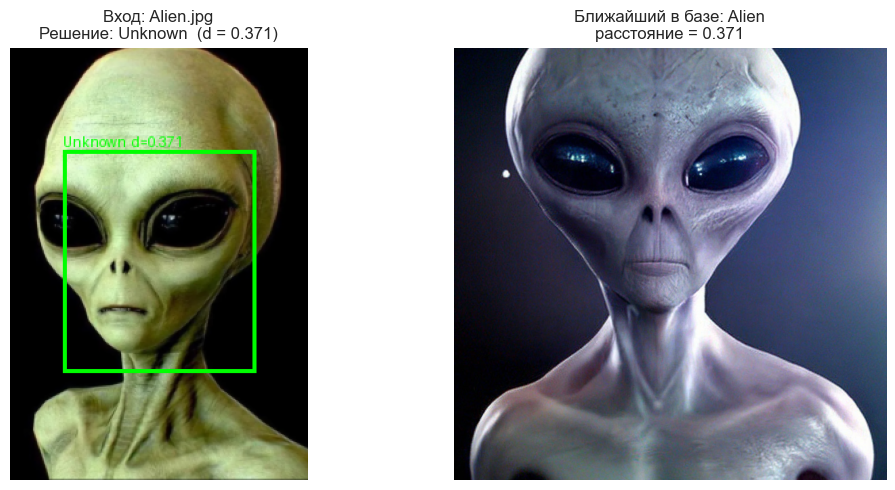


Alien: предсказание = Unknown  (ближайший = Alien, d = 0.3705, порог = 0.3)


In [24]:
img  = Image.open(alien_path).convert("RGB")
draw = ImageDraw.Draw(img)

if facial_area:
    x, y, w, h = facial_area["x"], facial_area["y"], facial_area["w"], facial_area["h"]
    draw.rectangle([x, y, x + w, y + h], outline="lime", width=3)
    draw.text((x, max(0, y - 12)), f"{pred}  d={min_dist:.3f}", fill="lime")

best_idx  = int(np.argmin([cosine_distance(alien_emb, e) for e in db_embeddings[min_person]]))
best_path = db_paths[min_person][best_idx]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(img)
axes[0].set_title(f"Вход: {alien_path.name}\nРешение: {pred}  (d = {min_dist:.3f})")
axes[0].axis("off")
axes[1].imshow(Image.open(best_path))
axes[1].set_title(f"Ближайший в базе: {min_person}\nрасстояние = {min_dist:.3f}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"\n{TARGET_PERSON}: предсказание = {pred}  "
      f"(ближайший = {min_person}, d = {min_dist:.4f}, порог = {THRESHOLD})")